# Snowman Logistics (NSE: SNOWMAN) — Business Analytics Case Study

Applies MSc Business Analytics coursework (Business Statistics, Advanced
Data Analytics, Supply Chain Strategy) to 13 quarters (Jun-2023 to Jun-2026)
and 12 years of publicly disclosed financial results.

**Techniques used, and what each is for:**
1. Data cleaning / feature engineering with pandas — turns raw disclosed numbers into the growth-rate/margin vocabulary an analyst actually reasons in.
2. Exploratory data analysis (seasonality, loss-making quarters, CAGR) — look at the data's structure *before* modelling it.
3. Simple linear regression — revenue trend over time (OLS, statsmodels) — a defensible, quantified growth rate instead of "it looks like it's growing."
4. Multiple linear regression — what drives net profit (driver analysis, with a VIF check for multicollinearity).
5. Forecast — next-quarter revenue with a 95% prediction interval.
6. matplotlib charts of the above.

**Source:** quarterly & annual results tables, [screener.in](https://www.screener.in/company/SNOWMAN/) (aggregated from NSE filings). Data is embedded below so this notebook runs standalone in Colab — no uploads needed.


## 0. Setup — install and import

In [1]:
# Colab ships pandas/numpy/matplotlib but not statsmodels -- install it first.
!pip install -q statsmodels

In [2]:
import io
import pandas as pd                 # tabular data: load, clean, group, engineer features
import numpy as np                  # numeric helpers (e.g. building the time-index array)
import matplotlib.pyplot as plt     # chart-drawing API
import statsmodels.api as sm        # regression with full statistical output (p-values, R^2, ...)
from statsmodels.stats.outliers_influence import variance_inflation_factor  # multicollinearity check

# One fixed colour palette reused across every chart, so a reader can tell
# "this is the same series" from chart to chart, and colours stay readable
# for colour-blind viewers.
SURFACE, INK, INK_SEC, INK_MUTE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams["font.family"] = "DejaVu Sans"
print("Setup complete.")

Setup complete.


## 1. Load the data

Embedded directly as CSV text (rather than a file path) so this cell is all
you need — no upload step, no Google Drive mount. In the GitHub repo version
of this project, the same content lives in `quarterly_results.csv` and
`annual_results.csv` alongside this notebook.

In [3]:
QUARTERLY_CSV = """quarter_end,sales_cr,expenses_cr,op_profit_cr,opm_pct,other_income_cr,interest_cr,depreciation_cr,pbt_cr,tax_pct,net_profit_cr
2023-06-30,128.77,104.55,24.22,18.81,1.20,5.60,13.61,6.21,45.57,3.38
2023-09-30,124.02,100.01,24.01,19.36,1.53,6.05,14.83,4.66,37.12,2.93
2023-12-31,124.05,97.72,26.33,21.23,1.17,5.86,15.10,6.54,35.02,4.25
2024-03-31,126.54,99.54,27.00,21.34,2.86,6.29,15.73,7.84,72.58,2.15
2024-06-30,140.23,116.79,23.44,16.72,0.77,5.98,15.71,2.52,28.97,1.79
2024-09-30,143.45,121.42,22.03,15.36,1.07,6.33,15.93,0.84,26.19,0.61
2024-12-31,131.85,112.09,19.76,14.99,2.07,6.35,16.09,-0.61,-1.64,-0.61
2025-03-31,137.01,112.96,24.05,17.55,0.33,5.78,15.34,3.26,-19.94,3.90
2025-06-30,162.70,138.35,24.35,14.97,0.74,5.63,15.51,3.95,35.44,2.54
2025-09-30,155.65,135.66,19.99,12.84,0.57,7.41,17.38,-4.23,-30.97,-2.91
2025-12-31,143.72,120.94,22.78,15.85,-1.48,7.07,17.42,-3.19,-41.38,-1.87
2026-03-31,142.31,118.52,23.79,16.72,1.06,6.65,17.28,0.92,-502.17,5.54
2026-06-30,177.68,149.07,28.61,16.10,2.32,6.52,17.38,7.03,35.42,4.55
"""

ANNUAL_CSV = """fy_end,sales_cr,expenses_cr,op_profit_cr,opm_pct,other_income_cr,interest_cr,depreciation_cr,pbt_cr,tax_pct,net_profit_cr
2015-03-31,203,156,47,23,5,12,25,15,-68,25
2016-03-31,225,176,49,22,3,9,30,12,-75,21
2017-03-31,189,153,36,19,-2,11,39,-15,-68,-5
2018-03-31,194,150,44,23,4,12,40,-4,0,-4
2019-03-31,233,174,59,25,3,10,41,11,10,10
2020-03-31,240,179,61,26,3,20,51,-6,138,-15
2021-03-31,237,172,65,27,3,17,49,2,98,0
2022-03-31,286,216,70,25,4,18,51,4,58,2
2023-03-31,418,329,89,21,8,22,52,22,38,13
2024-03-31,503,402,102,20,7,24,59,25,50,13
2025-03-31,553,463,89,16,4,24,63,6,5,6
2026-03-31,604,514,91,15,1,27,68,-3,-229,3
"""

# parse_dates=[...] tells pandas the date column is a real date, not text --
# needed so we can sort chronologically and later do date arithmetic (CAGR).
df = pd.read_csv(io.StringIO(QUARTERLY_CSV), parse_dates=["quarter_end"])

# Every downstream step (regression, growth rates, moving windows) assumes
# the rows are in time order -- sort explicitly rather than trust row order.
df = df.sort_values("quarter_end").reset_index(drop=True)

df.head()

,quarter_end,sales_cr,expenses_cr,op_profit_cr,opm_pct,other_income_cr,interest_cr,depreciation_cr,pbt_cr,tax_pct,net_profit_cr
0,2023-06-30,128.77,104.55,24.22,18.81,1.20,5.60,13.61,6.21,45.57,3.38
1,2023-09-30,124.02,100.01,24.01,19.36,1.53,6.05,14.83,4.66,37.12,2.93
2,2023-12-31,124.05,97.72,26.33,21.23,1.17,5.86,15.10,6.54,35.02,4.25
3,2024-03-31,126.54,99.54,27.00,21.34,2.86,6.29,15.73,7.84,72.58,2.15
4,2024-06-30,140.23,116.79,23.44,16.72,0.77,5.98,15.71,2.52,28.97,1.79


## 2. Feature engineering

Columns that aren't in the raw file but are derived from it — this is what
turns raw sales/profit numbers into the growth-rate and profitability
language an analyst actually reasons in.

In [4]:
# A simple 0, 1, 2, 3 ... counter standing in for "time." Regression needs a
# numeric x-axis; a date column can't be fed into OLS() directly.
df["quarter_idx"] = np.arange(len(df))

# pct_change(4) = % change vs. 4 rows ago. Since the data is quarterly,
# "4 rows ago" = the same quarter last year -> year-over-year growth.
df["yoy_sales_growth_pct"] = df["sales_cr"].pct_change(4) * 100

# pct_change(1) = % change vs. the immediately preceding row -> quarter-on-quarter growth.
df["qoq_sales_growth_pct"] = df["sales_cr"].pct_change(1) * 100

# Net margin: profit as a % of sales -- the standard profitability ratio.
df["net_margin_pct"] = df["net_profit_cr"] / df["sales_cr"] * 100

# Tag each quarter with its position in the fiscal year (Apr-Jun = Q1, ...,
# Jan-Mar = Q4) so we can check for seasonality below.
df["fiscal_quarter"] = df["quarter_end"].dt.month.map({6: "Q1", 9: "Q2", 12: "Q3", 3: "Q4"})

df[["quarter_end", "sales_cr", "opm_pct", "net_profit_cr", "net_margin_pct"]]

,quarter_end,sales_cr,opm_pct,net_profit_cr,net_margin_pct
0,2023-06-30,128.77,18.81,3.38,2.624835
1,2023-09-30,124.02,19.36,2.93,2.362522
2,2023-12-31,124.05,21.23,4.25,3.426038
3,2024-03-31,126.54,21.34,2.15,1.699067
4,2024-06-30,140.23,16.72,1.79,1.276474
5,2024-09-30,143.45,15.36,0.61,0.425235
6,2024-12-31,131.85,14.99,-0.61,-0.462647
7,2025-03-31,137.01,17.55,3.90,2.846508
8,2025-06-30,162.70,14.97,2.54,1.561156
9,2025-09-30,155.65,12.84,-2.91,-1.869579


## 3. Exploratory data analysis (EDA)

Look at the data's structure **before** fitting any model to it — this is
what catches "is that a real trend, or just a seasonal pattern?" before it
misleads a regression.

In [5]:
# --- Seasonality check ---
# groupby + agg: bucket the 13 quarters by fiscal_quarter (Q1..Q4) and
# summarise sales within each bucket. If one quarter is consistently
# higher/lower, that's seasonality, not growth.
seasonal = df.groupby("fiscal_quarter")["sales_cr"].agg(["mean", "std", "count"])
seasonal.reindex(["Q1", "Q2", "Q3", "Q4"])

,mean,std,count
fiscal_quarter,,,
Q1,152.345000,21.997288,4
Q2,141.040000,15.952125,3
Q3,133.206667,9.904930,3
Q4,135.286667,8.025001,3


In [6]:
# --- Loss-making quarters ---
# A simple boolean filter -- the kind of first-pass check a business analyst
# runs before any modelling, just to know how often the company lost money.
loss_quarters = df[df["net_profit_cr"] < 0][["quarter_end", "sales_cr", "net_profit_cr", "net_margin_pct"]]
print(f"{len(loss_quarters)} of {len(df)} quarters were loss-making.")
loss_quarters

3 of 13 quarters were loss-making.


,quarter_end,sales_cr,net_profit_cr,net_margin_pct
6,2024-12-31,131.85,-0.61,-0.462647
9,2025-09-30,155.65,-2.91,-1.869579
10,2025-12-31,143.72,-1.87,-1.301141


In [7]:
# --- Long-run annual revenue CAGR ---
# CAGR answers "if revenue had grown at one smooth constant rate every year
# from the first year to the last, what would that rate have to be?" -- a
# single, standard number for comparing long-run growth to a benchmark.
annual = pd.read_csv(io.StringIO(ANNUAL_CSV), parse_dates=["fy_end"]).sort_values("fy_end")
first_year, last_year = annual.iloc[0], annual.iloc[-1]
years_elapsed = (last_year["fy_end"] - first_year["fy_end"]).days / 365.25

# CAGR formula: (end_value / start_value) ^ (1 / years) - 1
cagr_pct = ((last_year["sales_cr"] / first_year["sales_cr"]) ** (1 / years_elapsed) - 1) * 100

print(f"FY{first_year['fy_end'].year} sales: Rs {first_year['sales_cr']:.0f} cr "
      f"-> FY{last_year['fy_end'].year} sales: Rs {last_year['sales_cr']:.0f} cr "
      f"over {years_elapsed:.1f} years")
print(f"Revenue CAGR: {cagr_pct:.2f}% per year")

FY2015 sales: Rs 203 cr -> FY2026 sales: Rs 604 cr over 11.0 years
Revenue CAGR: 10.42% per year


## 4. Regression 1 — revenue trend over time (simple linear regression)

`sales_cr ~ quarter_idx`

Fits the straight line `sales = intercept + slope * quarter_idx` that
minimises the total squared distance to every actual data point
("Ordinary Least Squares" — OLS). It turns "revenue looks like it's
growing" into a specific, testable number with a confidence range.

In [8]:
# add_constant() is required: without it, statsmodels forces the fitted line
# through the origin (0,0), which is almost never the right assumption. This
# adds a column of 1s so the model can also fit its own intercept.
X1 = sm.add_constant(df["quarter_idx"])
y1 = df["sales_cr"]
trend_model = sm.OLS(y1, X1).fit()
print(trend_model.summary())

                            OLS Regression Results                            
Dep. Variable:               sales_cr   R-squared:                       0.620
Model:                            OLS   Adj. R-squared:                  0.585
Method:                 Least Squares   F-statistic:                     17.95
Date:                Tue, 22 Sep 2026   Prob (F-statistic):            0.00140
Time:                        17:16:42   Log-Likelihood:                -47.694
No. Observations:                  13   AIC:                             99.39
Df Residuals:                      11   BIC:                             100.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         121.9516      5.405     22.562      

In [9]:
slope = trend_model.params["quarter_idx"]   # Rs crore gained, on average, per quarter
r2_trend = trend_model.rsquared             # % of variation in sales explained by time alone
print(f"Revenue is growing by an estimated Rs {slope:.2f} crore per quarter "
      f"(R-squared = {r2_trend:.3f}).")

# Forecast the NEXT quarter (one step past the last observed quarter_idx),
# with a 95% prediction interval -- the range the model expects the true
# value to fall in 95% of the time, given how noisy the historical fit was.
next_idx = len(df)
pred = trend_model.get_prediction([1, next_idx])
pred_summary = pred.summary_frame(alpha=0.05)
print(f"Forecast for the next quarter (idx {next_idx}): "
      f"Rs {pred_summary['mean'].iloc[0]:.1f} cr "
      f"(95% PI: {pred_summary['obs_ci_lower'].iloc[0]:.1f} - {pred_summary['obs_ci_upper'].iloc[0]:.1f} cr)")

Revenue is growing by an estimated Rs 3.24 crore per quarter (R-squared = 0.620).
Forecast for the next quarter (idx 13): Rs 164.1 cr (95% PI: 137.7 - 190.4 cr)


## 5. Regression 2 — what drives net profit? (multiple linear regression)

`net_profit_cr ~ sales_cr + depreciation_cr + interest_cr + other_income_cr`

"What drives profit?" is a multi-cause question — sales, depreciation,
interest and other income all move together. Multiple regression fits all
four predictors **at once**, so each coefficient represents "the effect of
this variable, holding the other three constant" — fitting them one at a
time would double-count effects that overlap.

In [10]:
drivers = ["sales_cr", "depreciation_cr", "interest_cr", "other_income_cr"]
X2 = sm.add_constant(df[drivers])
y2 = df["net_profit_cr"]
driver_model = sm.OLS(y2, X2).fit()
print(driver_model.summary())

                            OLS Regression Results                            
Dep. Variable:          net_profit_cr   R-squared:                       0.567
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     2.623
Date:                Tue, 22 Sep 2026   Prob (F-statistic):              0.115
Time:                        17:16:42   Log-Likelihood:                -24.701
No. Observations:                  13   AIC:                             59.40
Df Residuals:                       8   BIC:                             62.23
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              11.0912      8.557     

In [11]:
# --- Multicollinearity check (VIF) ---
# Multiple regression assumes the predictors are reasonably independent of
# each other. If two predictors move together (e.g. depreciation rises as
# the company adds warehouses, which also drives sales up), the model can't
# cleanly separate their individual effects, and coefficients can become
# unstable. VIF > 5 is the usual rule-of-thumb warning threshold.
vif_data = pd.DataFrame({
    "feature": drivers,
    "VIF": [variance_inflation_factor(X2[drivers].values, i) for i in range(len(drivers))]
})
print("Variance Inflation Factors (VIF > 5 flags multicollinearity):")
vif_data

Variance Inflation Factors (VIF > 5 flags multicollinearity):


,feature,VIF
0,sales_cr,2.024932
1,depreciation_cr,6.723516
2,interest_cr,4.823911
3,other_income_cr,1.068704


In [12]:
# p-value < 0.05 is the conventional cutoff for "statistically significant" --
# i.e. this effect is unlikely to be pure noise.
sig_terms = driver_model.pvalues[driver_model.pvalues < 0.05].index.tolist()
sig_terms = [t for t in sig_terms if t != "const"]
print(f"Statistically significant drivers (p < 0.05): {sig_terms if sig_terms else 'none at this sample size'}")
print(f"Model R-squared: {driver_model.rsquared:.3f} "
      f"(adj. R-squared: {driver_model.rsquared_adj:.3f}, n={len(df)})")
print("Caveat: n=13 quarters is a small sample for 4 predictors -- treat "
      "coefficients as directional, not final, and prefer the adjusted R-squared "
      "(it penalises the score for adding predictors that don't really help, "
      "unlike plain R-squared which never decreases as you add more variables).")

Statistically significant drivers (p < 0.05): ['interest_cr']
Model R-squared: 0.567 (adj. R-squared: 0.351, n=13)
Caveat: n=13 quarters is a small sample for 4 predictors -- treat coefficients as directional, not final, and prefer the adjusted R-squared (it penalises the score for adding predictors that don't really help, unlike plain R-squared which never decreases as you add more variables).


## 6. Charts

Turn the two regressions above into pictures that carry the finding without
needing the printed stats table.

In [13]:
def style_ax(ax):
    """Shared chart styling so every chart looks like one consistent system:
    same background, faint gridlines, no distracting box around the plot,
    muted axis labels."""
    ax.set_facecolor(SURFACE)
    ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
    ax.set_axisbelow(True)                      # keep gridlines behind the bars/points
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)     # remove the box, keep only the x-axis line
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(axis="x", length=0, labelsize=9, colors=INK_MUTE)
    ax.tick_params(axis="y", length=0, labelsize=9, colors=INK_MUTE)

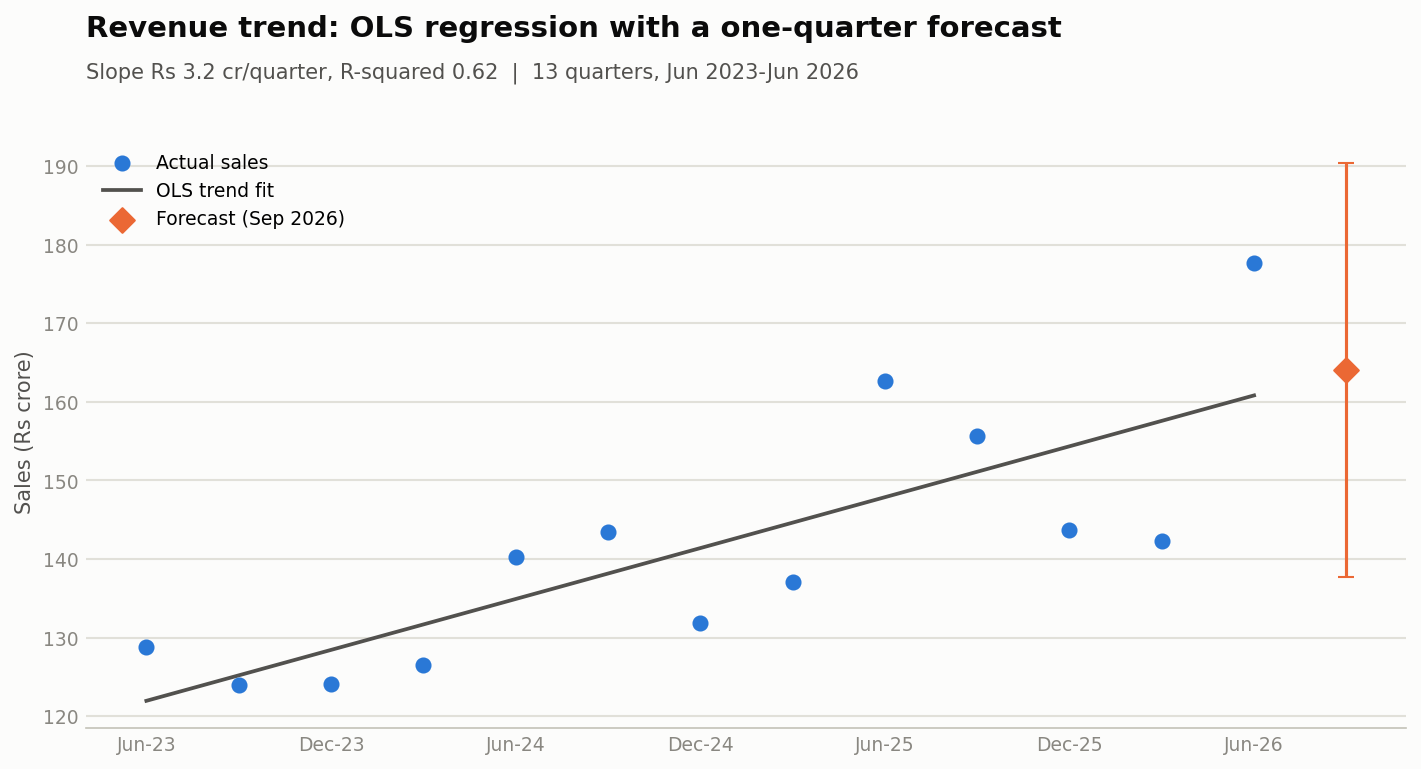

In [14]:
# --- Chart 1: revenue trend -- actual points, the OLS fitted line, and the
#     next-quarter forecast with its 95% prediction-interval error bar ---
fig = plt.figure(figsize=(10, 5.8), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax = fig.add_axes([0.08, 0.12, 0.88, 0.68])   # [left, bottom, width, height] in figure fractions
style_ax(ax)

ax.scatter(df["quarter_idx"], df["sales_cr"], color=BLUE, zorder=3, s=45, label="Actual sales")

fitted = trend_model.predict(X1)
ax.plot(df["quarter_idx"], fitted, color=INK_SEC, linewidth=1.8, zorder=2, label="OLS trend fit")

ax.scatter([next_idx], [pred_summary["mean"].iloc[0]], color=ORANGE, zorder=4, s=70,
           marker="D", label="Forecast (Sep 2026)")
ax.errorbar([next_idx], [pred_summary["mean"].iloc[0]],
            yerr=[[pred_summary["mean"].iloc[0] - pred_summary["obs_ci_lower"].iloc[0]],
                  [pred_summary["obs_ci_upper"].iloc[0] - pred_summary["mean"].iloc[0]]],
            color=ORANGE, capsize=4, zorder=4)

xt = list(df["quarter_idx"]) + [next_idx]
xl = [d.strftime("%b-%y") for d in df["quarter_end"]] + ["Forecast"]
ax.set_xticks(xt[::2])
ax.set_xticklabels([xl[i] for i in range(0, len(xl), 2)], rotation=0)
ax.set_ylabel("Sales (Rs crore)", fontsize=10, color=INK_SEC)
ax.legend(frameon=False, fontsize=9, loc="upper left")

fig.text(0.08, 0.94, "Revenue trend: OLS regression with a one-quarter forecast", fontsize=14,
          color=INK, weight="bold", ha="left", va="top")
fig.text(0.08, 0.885, f"Slope Rs {slope:.1f} cr/quarter, R-squared {r2_trend:.2f}  |  13 quarters, Jun 2023-Jun 2026",
          fontsize=10, color=INK_SEC, ha="left", va="top")

plt.show()

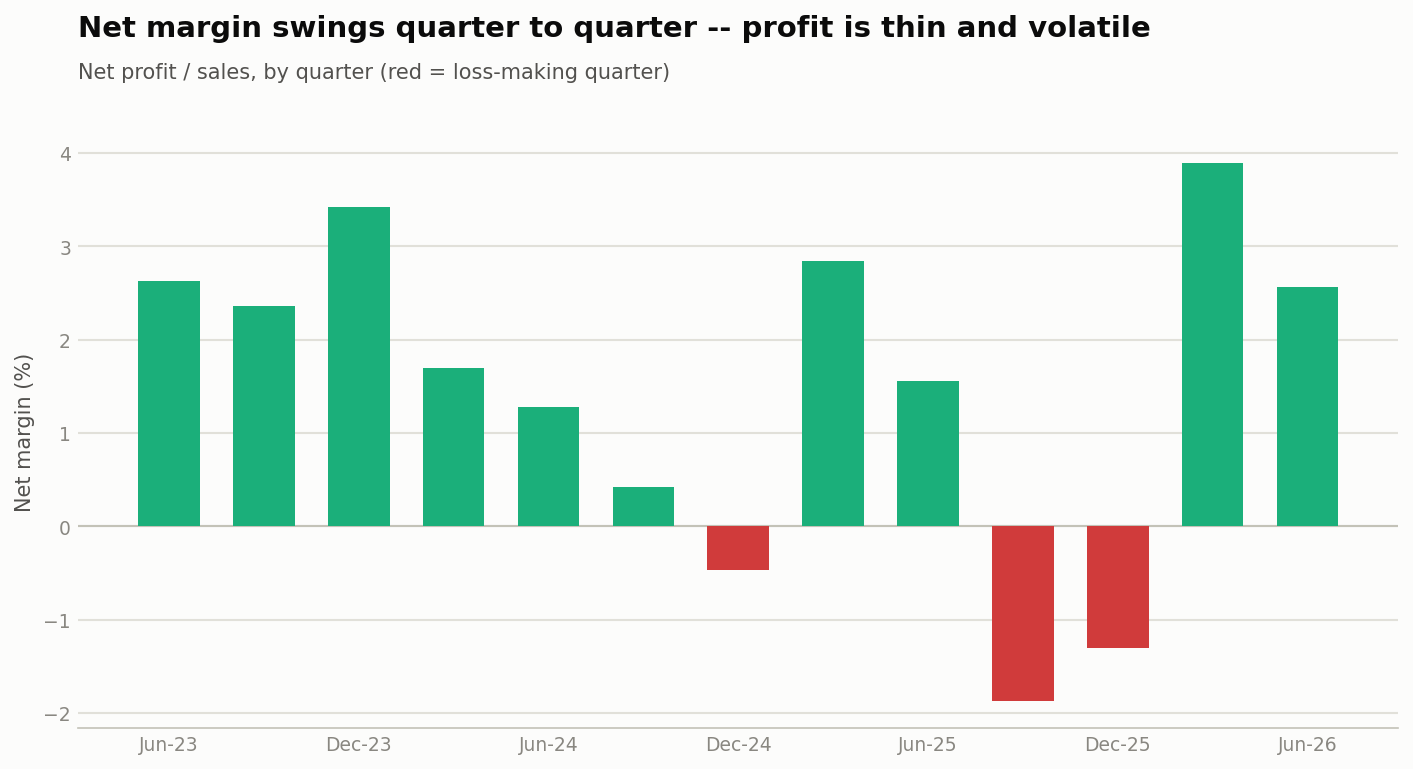

In [15]:
# --- Chart 2: net margin by quarter, coloured by profit vs. loss ---
fig = plt.figure(figsize=(10, 5.8), dpi=150)
fig.patch.set_facecolor(SURFACE)
ax = fig.add_axes([0.08, 0.12, 0.88, 0.68])
style_ax(ax)

# Colour each bar by sign: aqua for a profitable quarter, red for a loss --
# makes the loss-making quarters found above visible at a glance.
colors = [AQUA if v >= 0 else "#d03b3b" for v in df["net_margin_pct"]]
ax.bar(df["quarter_idx"], df["net_margin_pct"], color=colors, width=0.65, zorder=3)
ax.axhline(0, color=BASELINE, linewidth=1)   # zero line, so "below zero" is unambiguous
ax.set_xticks(df["quarter_idx"][::2])
ax.set_xticklabels([d.strftime("%b-%y") for d in df["quarter_end"]][::2])
ax.set_ylabel("Net margin (%)", fontsize=10, color=INK_SEC)

fig.text(0.08, 0.94, "Net margin swings quarter to quarter -- profit is thin and volatile", fontsize=14,
          color=INK, weight="bold", ha="left", va="top")
fig.text(0.08, 0.885, "Net profit / sales, by quarter (red = loss-making quarter)",
          fontsize=10, color=INK_SEC, ha="left", va="top")

plt.show()

## 7. Summary

- **Revenue trend:** ≈ Rs 3.24 cr/quarter growth (R² = 0.62); next-quarter forecast ≈ Rs 164 cr (95% PI: Rs 138–190 cr).
- **Seasonality:** Apr–Jun is consistently the strongest quarter.
- **Profit drivers:** only interest expense is statistically significant (p = 0.04) at this sample size — a stated limitation, not a hidden one.
- **Net margin:** thin and volatile — 3 of 13 quarters were loss-making.
- **Long-run CAGR (FY2015–FY2026):** ≈ 10.4%/year.

See the project's `README.md` for full source notes and caveats.